In [1]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU is available
Number of GPUs: 1
GPU Name: Tesla V100-SXM2-32GB


In [2]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 10
n_datapoints = 50000
locs_range = 2
batch_size = 32

In [3]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 25 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]

                if data is not None:
                    logits = torch.nn.functional.log_softmax(out_mu,dim=-1) - total_counts.log() + l.log() #- softmax_shift
                    recon = pyro.sample('obs', dist.NegativeBinomial(total_count=total_counts, logits=logits,validate_args=False).to_event(1), obs=data)
                    b_dist = dist.Bernoulli(probs=1-((total_counts * torch.nn.functional.logsigmoid(-logits))).exp()).to_event(1)
                    b_out=pyro.sample("b",b_dist, obs=(data>0.).float())
                    return recon

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})


In [4]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 16*torch.rand(n_var)-8.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [5]:
(data>0).sum(0)

tensor([10005,   968,  4152,     0,  8414,    28,  4136,  4444,    80,     2,
         3810,  4960, 21632, 19377, 11126, 12960,     0,  2126,     0,    97,
           61, 17046,  3564,  1975,     3, 18248,   313,     6, 10628,  8279,
            0, 20964,    19,  2136,     1,  8800,     4,    34,    82,    46,
         2884,     1,  6294,  3133,     0,  5160,  2302,  2173,   225,    23,
         5605,     0,     0,  8101,     2,  6770, 13911,     2,  1880, 21156,
           66,   277,  4571,  2993,     5, 10298, 10491,  3118,     2,   623,
           19,  1025,  8221,  2671,     7,   124,    27,  4711,  3383,     0,
        14550,  8255,  1866,  1509,  1042,  5033,  6318,    91,     2,   467,
            0,  2643,     9,  2825,  6511,    10,  8773,    21, 21179,  3584,
           15,  5641,     2,     4,     3,   639,  4802,     0, 24365,  1681,
           88,    35,   109,  5439,  4190,     7,   176,  7305,     1,    29,
           85,     0,  4245,    66,    10,  1403, 13039,  8872, 

<Axes: ylabel='Count'>

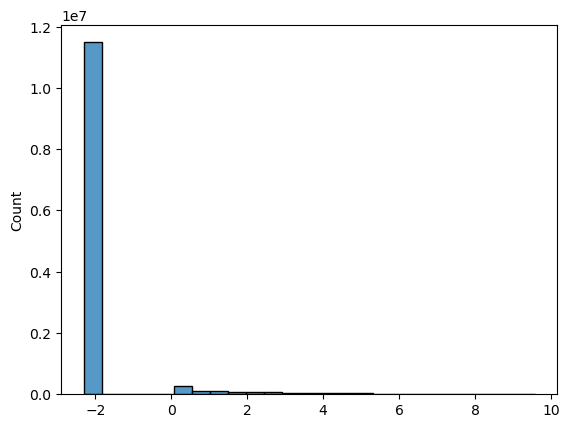

In [6]:
seaborn.histplot(np.log(data.flatten()+0.1))

<Axes: ylabel='Count'>

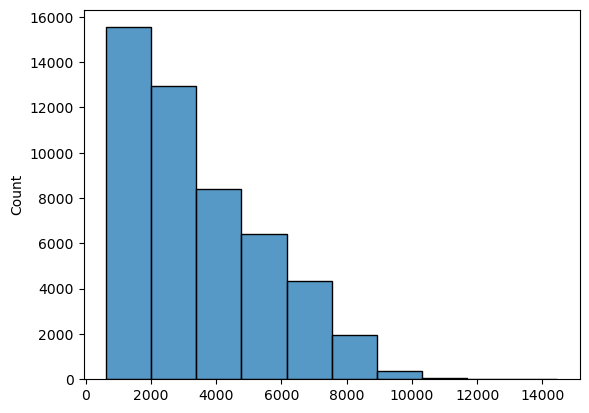

In [7]:
seaborn.histplot(data.sum(1).flatten(),bins=10)

In [8]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [9]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 30
losses = []

In [10]:
for i in tqdm.tqdm(range(num_iterations)):
    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  3%|▎         | 1/30 [00:38<18:39, 38.62s/it]

Iteration 0 : Loss 0.39121952652931213


  7%|▋         | 2/30 [01:11<16:32, 35.45s/it]

Iteration 1 : Loss 0.2965601682662964


 10%|█         | 3/30 [01:45<15:29, 34.44s/it]

...

 90%|█████████ | 27/30 [14:41<01:35, 31.75s/it]

Iteration 26 : Loss 0.18695202469825745


 93%|█████████▎| 28/30 [15:11<01:02, 31.31s/it]

Iteration 27 : Loss 0.20378294587135315


 93%|█████████▎| 28/30 [15:30<01:06, 33.23s/it]

KeyboardInterrupt



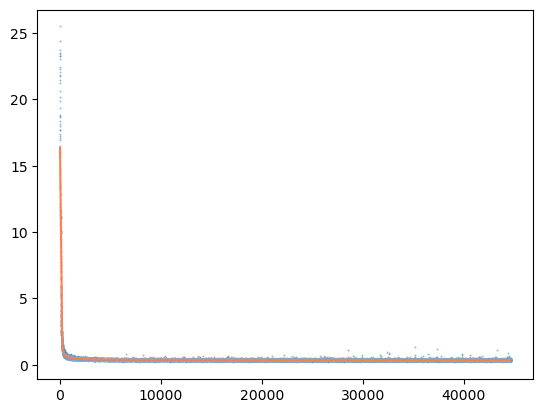

In [11]:
antipode.plotting.plot_loss(losses)

In [12]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [13]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [14]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


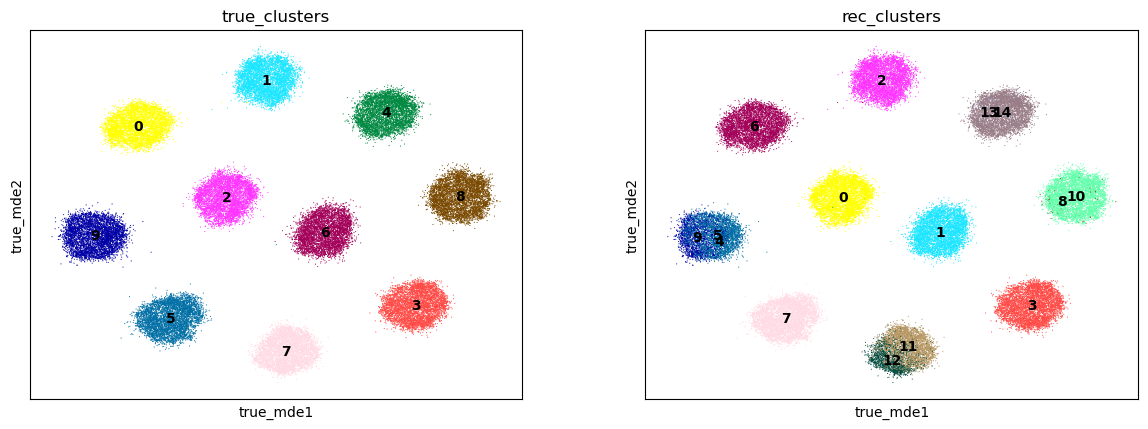

In [15]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


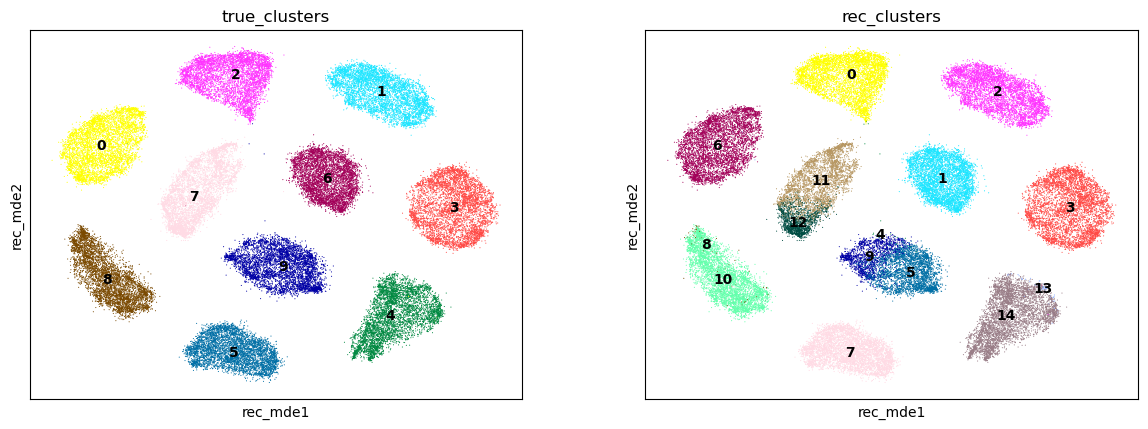

In [16]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [17]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = out_locs @ out_transform_matrix + out_intercept
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

100%|██████████| 15/15 [00:00<00:00, 271.67it/s]


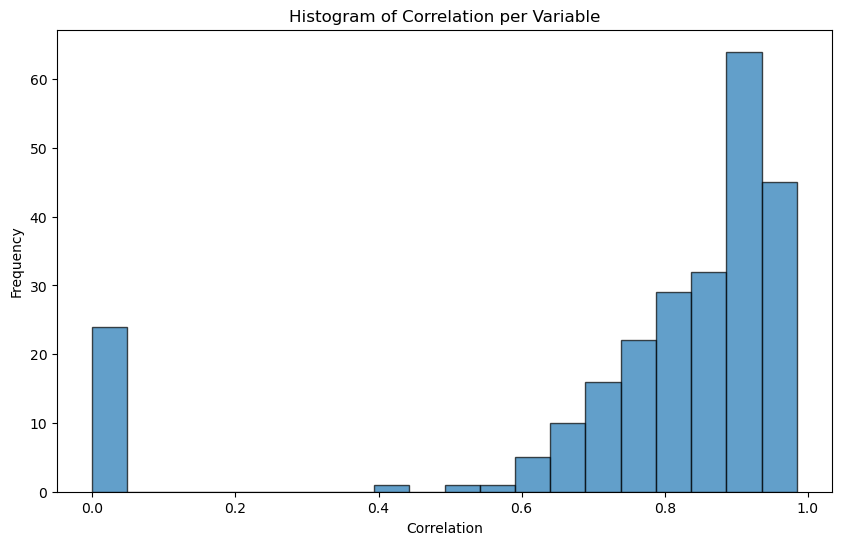

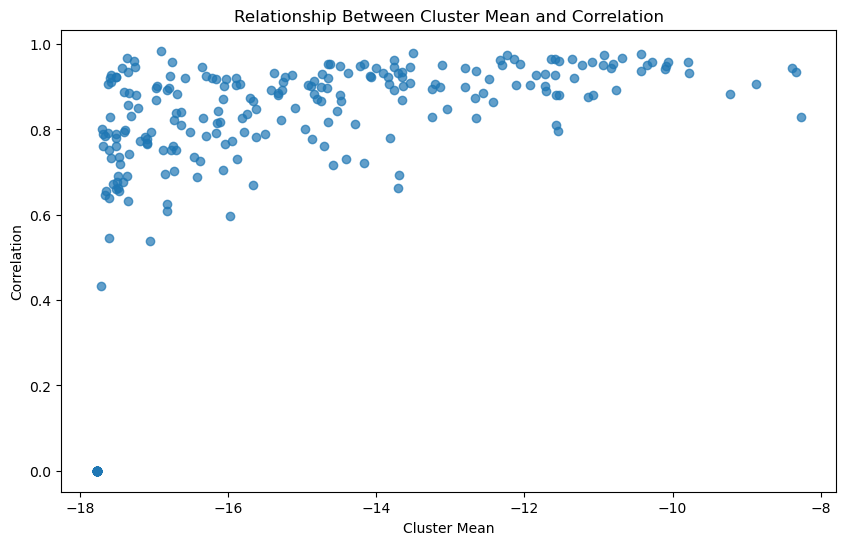

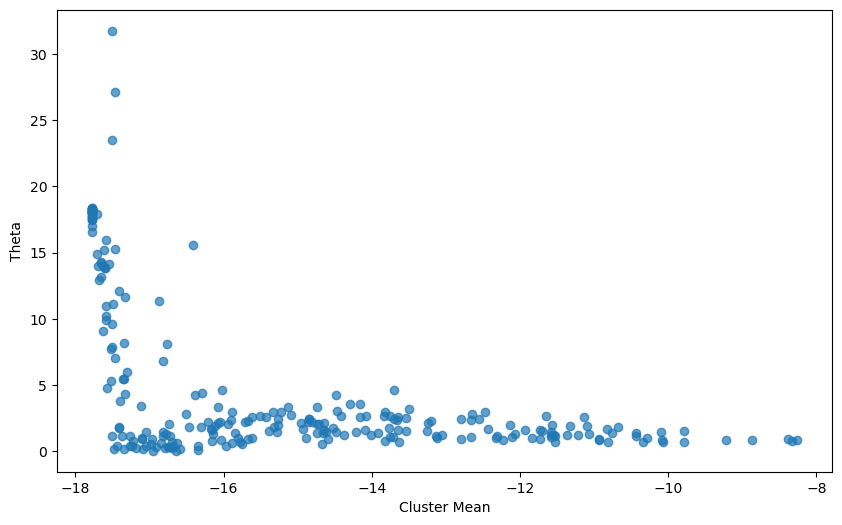

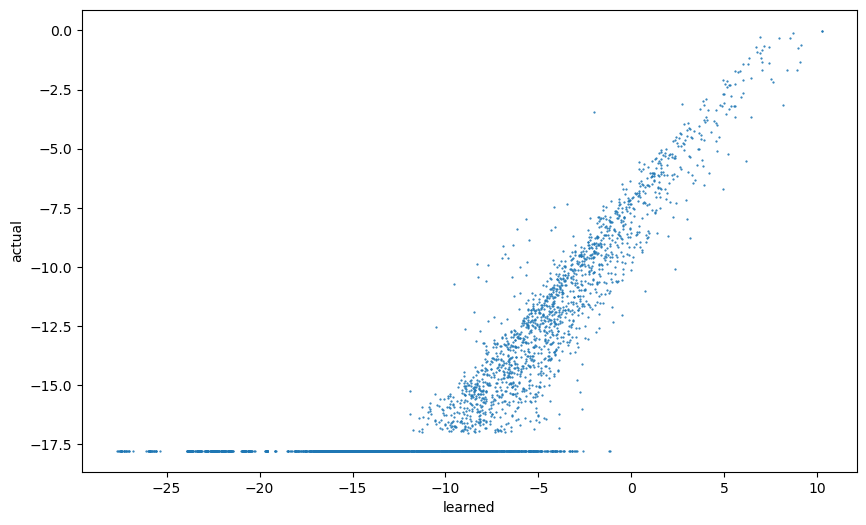

In [18]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
plt.scatter(learned_means.flatten(),actual_means.flatten(),s=0.3)
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()
